In [109]:
# =============================================================================
# IMPORTS AND ENVIRONMENT SETUP
# =============================================================================
# Import core libraries for numerics, data handling, and plotting
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
#import pandas_profiling
%matplotlib inline
!pip install tqdm

# Enable multiple expressions per cell in Jupyter (shows all results, not just last)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [110]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS — Titanic Dataset Overview
# =============================================================================

# Load a fresh copy of the Titanic dataset for initial exploration
titanic_eda = sns.load_dataset('titanic')

# — Dataset shape and basic statistics —
print('=' * 60)
print('TITANIC DATASET — EXPLORATORY DATA ANALYSIS')
print('=' * 60)
print(f'\nDataset Shape: {titanic_eda.shape[0]} rows x {titanic_eda.shape[1]} columns')
print(f"Overall Survival Rate: {titanic_eda['survived'].mean():.1%}")

print('\n— Missing Values —')
print(titanic_eda.isna().sum())

print('\n— Survival by Gender —')
print(titanic_eda.groupby('sex')['survived'].mean().round(3))

print('\n— Survival by Passenger Class —')
print(titanic_eda.groupby('pclass')['survived'].mean().round(3))

TITANIC DATASET — EXPLORATORY DATA ANALYSIS

Dataset Shape: 891 rows x 15 columns
Overall Survival Rate: 38.4%

— Missing Values —
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

— Survival by Gender —
sex
female    0.742
male      0.189
Name: survived, dtype: float64

— Survival by Passenger Class —
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


C:\Users\shash\AppData\Local\Temp\ipykernel_1852\3196728937.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


<Axes: xlabel='survived', ylabel='count'>

Text(0.5, 1.0, 'Survival Count (0 = Died, 1 = Survived)')

Text(0.5, 0, 'Survived')

<Axes: xlabel='sex', ylabel='count'>

Text(0.5, 1.0, 'Survival by Gender')

<Axes: xlabel='pclass', ylabel='count'>

Text(0.5, 1.0, 'Survival by Passenger Class')

Text(0.5, 0, 'Passenger Class')

<Axes: xlabel='age', ylabel='Count'>

Text(0.5, 1.0, 'Age Distribution by Survival Status')

Text(0.5, 1.02, 'Titanic EDA — Key Survival Patterns')

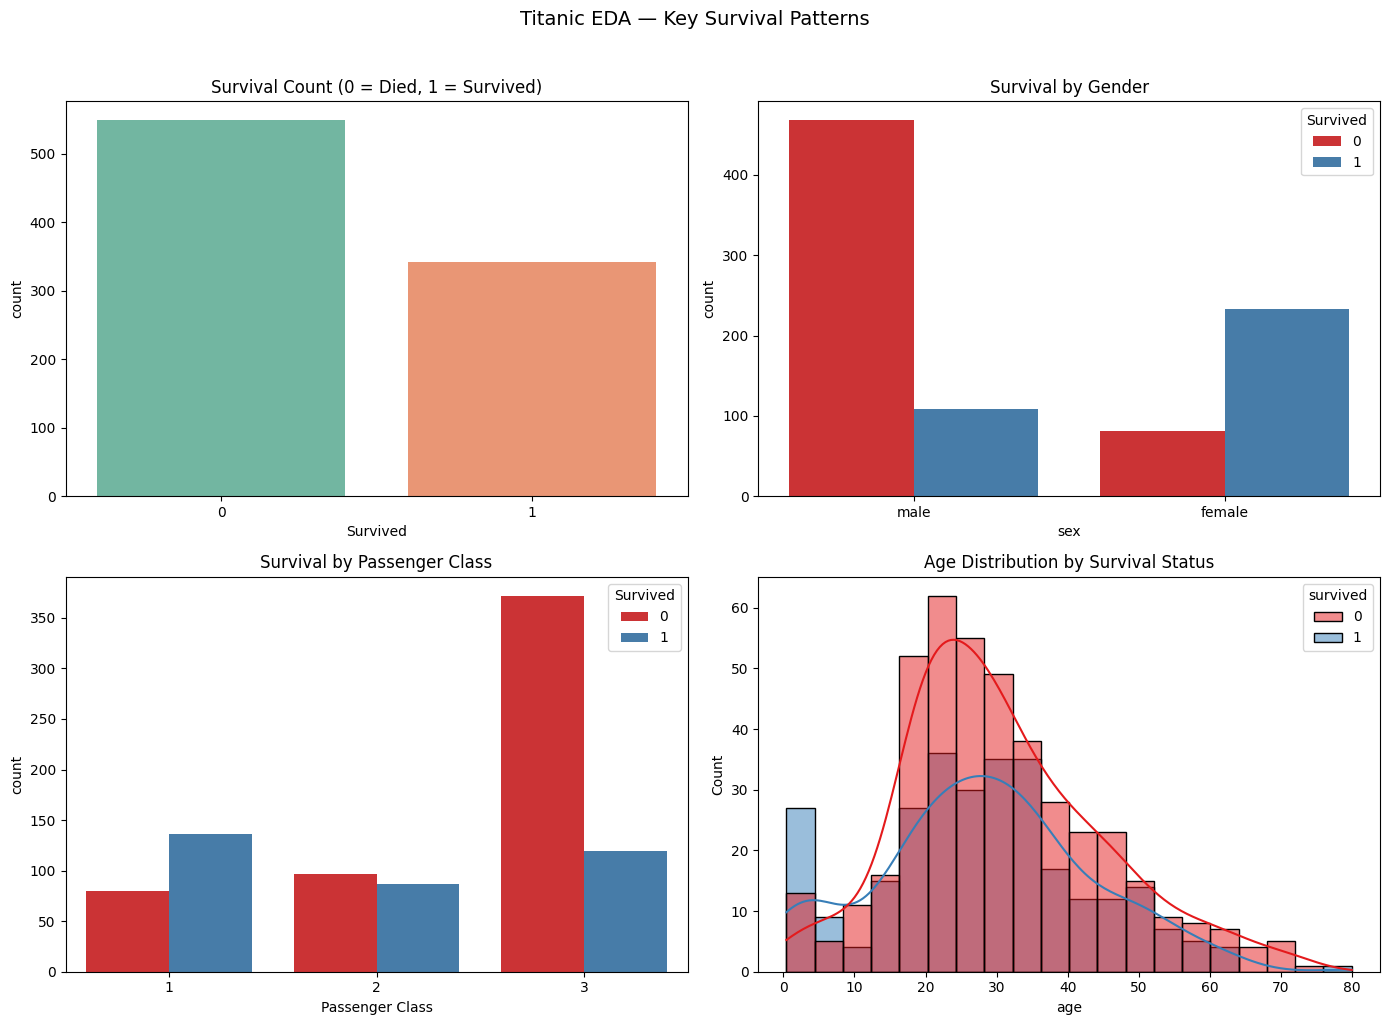

In [111]:
# =============================================================================
# CHART 1: OVERVIEW PANEL
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(
    data=titanic_eda,
    x='survived',
    ax=axes[0, 0],
    palette='Set2'
)
axes[0, 0].set_title('Survival Count (0 = Died, 1 = Survived)')
axes[0, 0].set_xlabel('Survived')

sns.countplot(
    data=titanic_eda,
    x='sex',
    hue='survived',
    ax=axes[0, 1],
    palette='Set1'
)
axes[0, 1].set_title('Survival by Gender')
axes[0, 1].legend(title='Survived')

sns.countplot(
    data=titanic_eda,
    x='pclass',
    hue='survived',
    ax=axes[1, 0],
    palette='Set1'
)
axes[1, 0].set_title('Survival by Passenger Class')
axes[1, 0].set_xlabel('Passenger Class')
axes[1, 0].legend(title='Survived')

sns.histplot(
    data=titanic_eda,
    x='age',
    hue='survived',
    kde=True,
    ax=axes[1, 1],
    palette='Set1'
)
axes[1, 1].set_title('Age Distribution by Survival Status')

plt.suptitle('Titanic EDA — Key Survival Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\shash\AppData\Local\Temp\ipykernel_1852\2716274516.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='survived', ylabel='fare'>

Text(0.5, 1.0, 'Fare Distribution by Survival Status')

Text(0.5, 0, 'Survived (0 = Died, 1 = Survived)')

<Axes: >

Text(0.5, 1.0, 'Missing Values by Column')

Text(0, 0.5, 'Count')

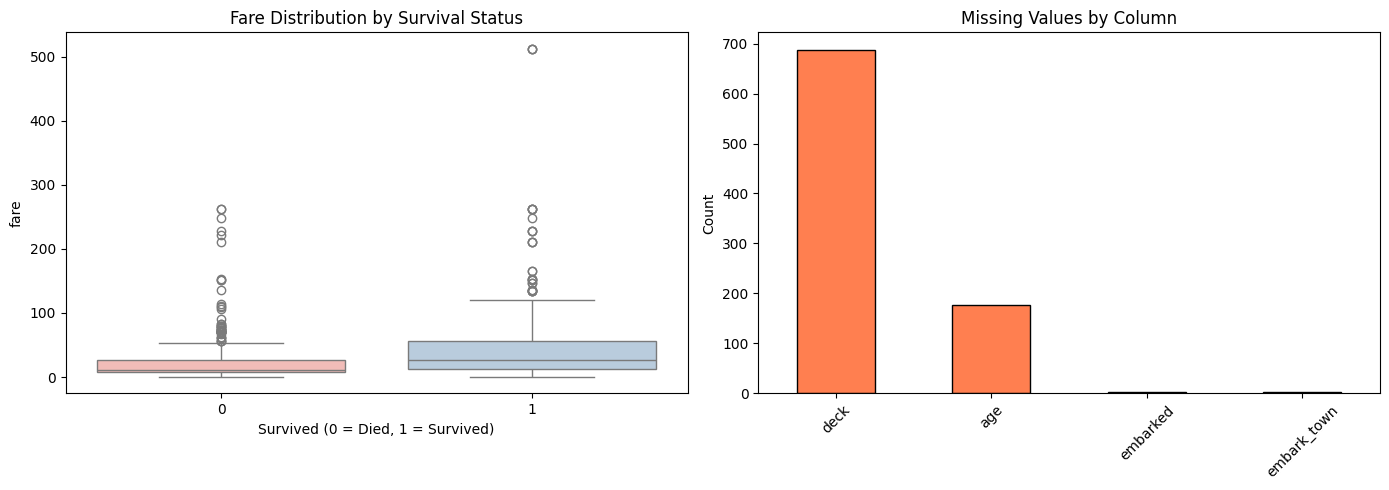

In [112]:
# =============================================================================
# CHART 2: FARE DISTRIBUTION AND MISSING VALUES
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=titanic_eda,
    x='survived',
    y='fare',
    ax=axes[0],
    palette='Pastel1'
)
axes[0].set_title('Fare Distribution by Survival Status')
axes[0].set_xlabel('Survived (0 = Died, 1 = Survived)')

missing = titanic_eda.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(
    kind='bar',
    ax=axes[1],
    color='coral',
    edgecolor='black'
)
axes[1].set_title('Missing Values by Column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap — Numeric Features')

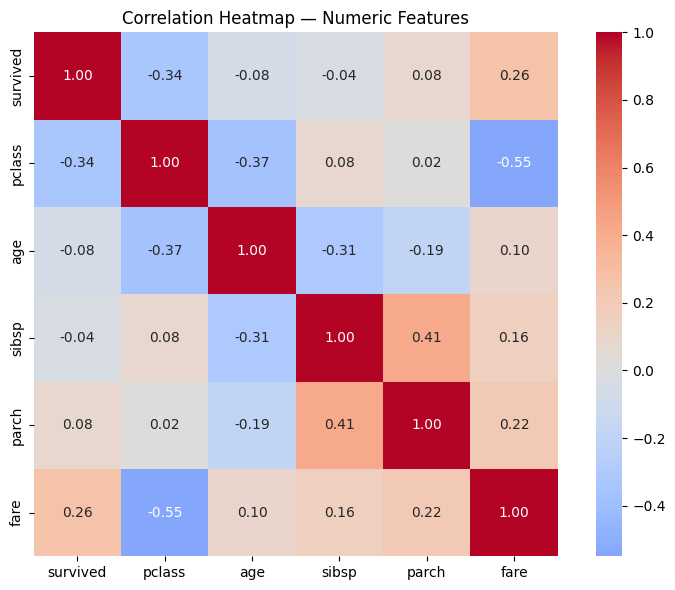

In [113]:
# =============================================================================
# CHART 3: CORRELATION HEATMAP
# =============================================================================
numeric_cols = titanic_eda.select_dtypes(include='number').columns
corr = titanic_eda[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [114]:
# =============================================================================
# LOAD TITANIC DATA
# =============================================================================
titanic = sns.load_dataset('titanic')

print("\nFirst 5 rows:")
print(titanic.head())

print("\nLast 5 rows:")
print(titanic.tail())



First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Last 5 rows:
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0 

In [115]:
# =============================================================================
# PROGRESS BAR DEMO (tqdm)
# =============================================================================
from tqdm import tqdm
from time import sleep

with tqdm(total=100) as pbar:
    for i in range(10):
        sleep(0.1)
        pbar.update(10)


 10%|█         | 10/100 [00:00<00:00, 98.94it/s]

True

 20%|██        | 20/100 [00:00<00:00, 96.50it/s]

True

 30%|███       | 30/100 [00:00<00:00, 95.98it/s]

True

 40%|████      | 40/100 [00:00<00:00, 95.66it/s]

True

 50%|█████     | 50/100 [00:00<00:00, 95.46it/s]

True

 60%|██████    | 60/100 [00:00<00:00, 95.30it/s]

True

 70%|███████   | 70/100 [00:00<00:00, 95.57it/s]

True

 80%|████████  | 80/100 [00:00<00:00, 95.70it/s]

True

 90%|█████████ | 90/100 [00:00<00:00, 95.66it/s]

True

100%|██████████| 100/100 [00:01<00:00, 95.88it/s]

True

100%|██████████| 100/100 [00:01<00:00, 95.52it/s]


In [116]:
# =============================================================================
# DROP REDUNDANT / LEAKAGE COLUMNS
# =============================================================================
titanic.drop(
    [
        'alive',
        'class',
        'who',
        'embark_town',
        'alone',
        'adult_male'
    ],
    axis=1,
    inplace=True
)

print("\nData Preview:")
print(titanic.head())

print("\nData Info:")
titanic.info()


Data Preview:
   survived  pclass     sex   age  sibsp  parch     fare embarked deck
0         0       3    male  22.0      1      0   7.2500        S  NaN
1         1       1  female  38.0      1      0  71.2833        C    C
2         1       3  female  26.0      0      0   7.9250        S  NaN
3         1       1  female  35.0      1      0  53.1000        S    C
4         0       3    male  35.0      0      0   8.0500        S  NaN

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    object  
 8   deck      203 non-null    category
dty

In [117]:
# =============================================================================
# HANDLE EMBARKED MISSING VALUES
# =============================================================================
print("\nEmbarked Distribution:")
print(titanic['embarked'].value_counts())

print("\nEmbarked Mode:")
print(titanic['embarked'].mode())

print("\nRows with Missing Embarked:")
print(titanic.iloc[[61, 684], :])

titanic['embarked'] = titanic['embarked'].fillna(
    titanic['embarked'].mode()[0]
)

print("\nRemaining Missing Values:")
print(titanic.isna().sum())

print("\nDataset Shape:")
print(titanic.shape)


Embarked Distribution:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Embarked Mode:
0    S
Name: embarked, dtype: object

Rows with Missing Embarked:
     survived  pclass     sex   age  sibsp  parch  fare embarked deck
61          1       1  female  38.0      0      0  80.0      NaN    B
684         0       2    male  60.0      1      1  39.0        S  NaN

Remaining Missing Values:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      0
deck        688
dtype: int64

Dataset Shape:
(891, 9)


In [118]:
# =============================================================================
# REMOVE DUPLICATES
# =============================================================================
titanic = titanic.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(titanic.shape)


Shape After Removing Duplicates:
(784, 9)


In [119]:
# =============================================================================
# EXPLORE MISSING AGE VALUES
# =============================================================================
titanic_age_missing = titanic[titanic['age'].isna()]

print("\nPassengers with Missing Age:")
print(titanic_age_missing.head())
print(titanic_age_missing.shape)

print("\nSelected Rows:")
print(titanic.iloc[[19, 26, 28], :])


Passengers with Missing Age:
    survived  pclass     sex  age  sibsp  parch     fare embarked deck
5          0       3    male  NaN      0      0   8.4583        Q  NaN
17         1       2    male  NaN      0      0  13.0000        S  NaN
19         1       3  female  NaN      0      0   7.2250        C  NaN
26         0       3    male  NaN      0      0   7.2250        C  NaN
28         1       3  female  NaN      0      0   7.8792        Q  NaN
(106, 9)

Selected Rows:
    survived  pclass     sex  age  sibsp  parch    fare embarked deck
19         1       3  female  NaN      0      0  7.2250        C  NaN
26         0       3    male  NaN      0      0  7.2250        C  NaN
28         1       3  female  NaN      0      0  7.8792        Q  NaN


In [120]:
# =============================================================================
# RENAME COLUMNS
# =============================================================================
titanic = titanic.rename(columns={
    'sex': 'gender',
    'sibsp': 'siblings_spouse',
    'parch': 'parents_child'
})

print("\nColumns:")
print(titanic.columns)


Columns:
Index(['survived', 'pclass', 'gender', 'age', 'siblings_spouse',
       'parents_child', 'fare', 'embarked', 'deck'],
      dtype='object')


In [121]:
# =============================================================================
# DECK COLUMN TREATMENT
# =============================================================================
titanic['deck'] = titanic['deck'].astype('object')
titanic['deck'] = titanic['deck'].fillna('Not Assigned')

print("\nDeck Missing Values:")
print(titanic['deck'].isna().sum())



Deck Missing Values:
0


In [122]:
# =============================================================================
# ENCODE CATEGORICAL VARIABLES
# =============================================================================
for col in titanic.columns:
    if titanic[col].dtype == 'object':
        titanic[col] = pd.Categorical(titanic[col]).codes

print("\nEncoded Dataset:")
print(titanic.head())


Encoded Dataset:
   survived  pclass  gender   age  siblings_spouse  parents_child     fare  \
0         0       3       1  22.0                1              0   7.2500   
1         1       1       0  38.0                1              0  71.2833   
2         1       3       0  26.0                0              0   7.9250   
3         1       1       0  35.0                1              0  53.1000   
4         0       3       1  35.0                0              0   8.0500   

   embarked  deck  
0         2     7  
1         0     2  
2         2     7  
3         2     2  
4         2     7  


In [123]:
# =============================================================================
# IMPUTE AGE WITH MEDIAN
# =============================================================================
print("\nAge Median:")
print(titanic['age'].median())

titanic['age'] = titanic['age'].fillna(
    titanic['age'].median()
)

# Fill any remaining numeric missing values
titanic = titanic.fillna(titanic.median())

print("\nMissing Values After Imputation:")
print(titanic.isna().sum())


Age Median:
28.25

Missing Values After Imputation:
survived           0
pclass             0
gender             0
age                0
siblings_spouse    0
parents_child      0
fare               0
embarked           0
deck               0
dtype: int64


In [124]:
# =============================================================================
# DESCRIPTIVE STATISTICS
# =============================================================================
print("\nDescriptive Statistics:")
print(titanic.describe())

print("\nQuantiles:")
print(
    titanic.quantile(
        [0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]
    )
)


Descriptive Statistics:


         survived      pclass      gender         age  siblings_spouse  \
count  784.000000  784.000000  784.000000  784.000000       784.000000   
mean     0.411990    2.243622    0.626276   29.650408         0.522959   
std      0.492507    0.855056    0.484101   13.734925         0.986231   
min      0.000000    1.000000    0.000000    0.420000         0.000000   
25%      0.000000    1.000000    0.000000   22.000000         0.000000   
50%      0.000000    3.000000    1.000000   28.250000         0.000000   
75%      1.000000    3.000000    1.000000   36.000000         1.000000   
max      1.000000    3.000000    1.000000   80.000000         8.000000   

       parents_child        fare    embarked        deck  
count     784.000000  784.000000  784.000000  784.000000  
mean        0.415816   34.711740    1.529337    5.808673  
std         0.836922   52.160151    0.803350    2.151747  
min         0.000000    0.000000    0.000000    0.000000  
25%         0.000000    8.050000    1.

<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Fare Distribution Before Clipping')

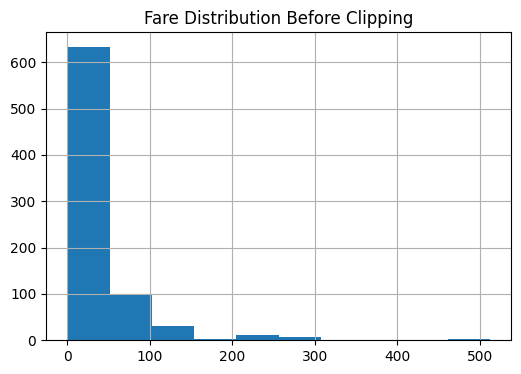

<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Fare Distribution After Clipping')

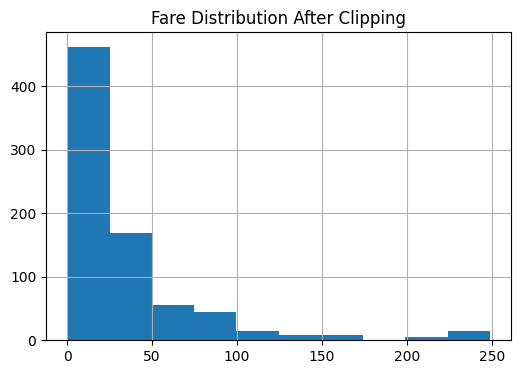


Statistics After Outlier Treatment:
         survived      pclass      gender         age  siblings_spouse  \
count  784.000000  784.000000  784.000000  784.000000       784.000000   
mean     0.411990    2.243622    0.626276   29.587194         0.506378   
std      0.492507    0.855056    0.484101   13.539720         0.899814   
min      0.000000    1.000000    0.000000    1.000000         0.000000   
25%      0.000000    1.000000    0.000000   22.000000         0.000000   
50%      0.000000    3.000000    1.000000   28.250000         0.000000   
75%      1.000000    3.000000    1.000000   36.000000         1.000000   
max      1.000000    3.000000    1.000000   65.170000         4.000000   

       parents_child        fare    embarked        deck  
count     784.000000  784.000000  784.000000  784.000000  
mean        0.406888   33.598625    1.529337    5.808673  
std         0.790430   44.436915    0.803350    2.151747  
min         0.000000    0.000000    0.000000    0.000000  
2

In [125]:
# =============================================================================
# OUTLIER ANALYSIS
# =============================================================================
plt.figure(figsize=(6, 4))
titanic['fare'].hist()
plt.title('Fare Distribution Before Clipping')
plt.show()

# Clip fare
titanic['fare'] = np.clip(
    titanic['fare'],
    0,
    249.00622
)

plt.figure(figsize=(6, 4))
titanic['fare'].hist()
plt.title('Fare Distribution After Clipping')
plt.show()

# Clip all numeric columns
for col in titanic.columns:
    outlier = titanic[col].quantile([0.01, 0.99]).values
    titanic[col] = np.clip(
        titanic[col],
        outlier[0],
        outlier[1]
    )

print("\nStatistics After Outlier Treatment:")
print(titanic.describe())

In [126]:
# =============================================================================
# TARGET BALANCE
# =============================================================================
print("\nClass Balance:")
print(titanic.groupby('survived').size())

print("\nDataset Shape:")
print(titanic.shape)


Class Balance:
survived
0    461
1    323
dtype: int64

Dataset Shape:
(784, 9)


In [127]:
# =============================================================================
# PREPARE FEATURES AND TARGET
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

X = titanic.drop(['survived'], axis=1)
y = titanic['survived']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)



Feature Shape: (784, 8)
Target Shape: (784,)


In [128]:
# =============================================================================
# MINMAX SCALER
# =============================================================================
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 1))

X_minmax = minmax_scaler.fit_transform(X)

X_minmax_df = pd.DataFrame(
    X_minmax,
    columns=X.columns
)

print("\nMinMax Scaled Data:")
print(X_minmax_df.head())


MinMax Scaled Data:
   pclass  gender       age  siblings_spouse  parents_child      fare  \
0     1.0     1.0  0.327256             0.25            0.0  0.029116   
1     0.0     0.0  0.576593             0.25            0.0  0.286271   
2     1.0     0.0  0.389590             0.00            0.0  0.031827   
3     0.0     0.0  0.529843             0.25            0.0  0.213248   
4     1.0     1.0  0.529843             0.00            0.0  0.032329   

   embarked      deck  
0       1.0  1.000000  
1       0.0  0.285714  
2       1.0  1.000000  
3       1.0  0.285714  
4       1.0  1.000000  


In [129]:
# =============================================================================
# STANDARD SCALER
# =============================================================================
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

X_scaled = std_scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nStandardized Data Summary:")
print(np.round(X_scaled_df.describe(), 2))


Standardized Data Summary:
       pclass  gender     age  siblings_spouse  parents_child    fare  \
count  784.00  784.00  784.00           784.00         784.00  784.00   
mean    -0.00   -0.00    0.00             0.00          -0.00    0.00   
std      1.00    1.00    1.00             1.00           1.00    1.00   
min     -1.46   -1.29   -2.11            -0.56          -0.52   -0.76   
25%     -1.46   -1.29   -0.56            -0.56          -0.52   -0.58   
50%      0.89    0.77   -0.10            -0.56          -0.52   -0.40   
75%      0.89    0.77    0.47             0.55           0.75    0.01   
max      0.89    0.77    2.63             3.89           4.55    4.85   

       embarked    deck  
count    784.00  784.00  
mean       0.00   -0.00  
std        1.00    1.00  
min       -1.90   -2.70  
25%       -0.66   -0.38  
50%        0.59    0.55  
75%        0.59    0.55  
max        0.59    0.55  


In [130]:
# =============================================================================
# TRAIN TEST SPLIT
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df,
    y,
    test_size=0.20,
    random_state=999
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

print(
    "\nTrain Survival Rate:",
    np.round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Test Survival Rate:",
    np.round(y_test.mean() * 100, 2),
    "%"
)


Train Shape: (627, 8)
Test Shape: (157, 8)

Train Survival Rate: 40.83 %
Test Survival Rate: 42.68 %


In [131]:
# =============================================================================
# LOGISTIC REGRESSION MODEL
# =============================================================================
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [132]:
# =============================================================================
# PREDICTIONS
# =============================================================================
predicted = log.predict(X_test)

print("\nClassification Report:")
print(metrics.classification_report(y_test, predicted))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        90
           1       0.76      0.70      0.73        67

    accuracy                           0.78       157
   macro avg       0.77      0.77      0.77       157
weighted avg       0.78      0.78      0.78       157




Confusion Matrix:
[[75 15]
 [20 47]]


<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix')

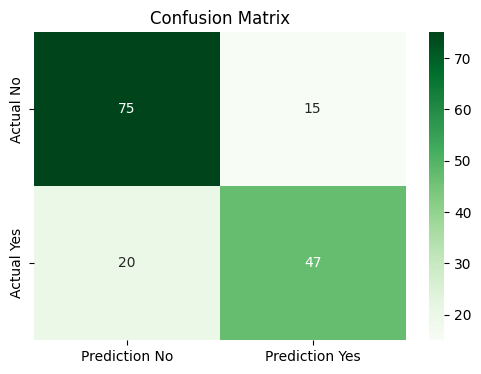

In [133]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================
df_confusion = metrics.confusion_matrix(
    y_test,
    predicted
)

print("\nConfusion Matrix:")
print(df_confusion)

plt.figure(figsize=(6, 4))
sns.heatmap(
    df_confusion,
    cmap='Greens',
    xticklabels=['Prediction No', 'Prediction Yes'],
    yticklabels=['Actual No', 'Actual Yes'],
    annot=True,
    fmt='d'
)
plt.title('Confusion Matrix')
plt.show()


In [134]:
# =============================================================================
# ACCURACY
# =============================================================================
accuracy = metrics.accuracy_score(
    y_test,
    predicted
)

print("\nAccuracy Score:")
print(round(accuracy, 4))


Accuracy Score:
0.7771


In [135]:
# =============================================================================
# MODEL COEFFICIENTS
# =============================================================================
coeff = pd.concat(
    [
        pd.DataFrame(X.columns),
        pd.DataFrame(log.coef_.T)
    ],
    axis=1
)

coeff.columns = ['Variable', 'Coeff']

print("\nModel Coefficients:")
print(coeff)



Model Coefficients:
          Variable     Coeff
0           pclass -0.781079
1           gender -1.202326
2              age -0.577106
3  siblings_spouse -0.302020
4    parents_child -0.166935
5             fare  0.020301
6         embarked -0.148059
7             deck -0.192441


In [136]:
# =============================================================================
# PROBABILITY PREDICTIONS
# =============================================================================
predicted_prob = log.predict_proba(X_test)

predicted_prob_df = pd.DataFrame(predicted_prob)
predicted_classes_df = pd.DataFrame(predicted)
y_actual_df = pd.DataFrame(y_test.values)

predicted_df = pd.concat(
    [
        predicted_prob_df,
        predicted_classes_df,
        y_actual_df
    ],
    axis=1
)

predicted_df.columns = [
    'Prob_0',
    'Prob_1',
    'Predicted_Class',
    'Actual_Class'
]

print("\nSample Probability Predictions:")
print(predicted_df.sample(20))


Sample Probability Predictions:
       Prob_0    Prob_1  Predicted_Class  Actual_Class
22   0.756976  0.243024                0             0
46   0.488861  0.511139                1             1
78   0.320390  0.679610                1             1
91   0.129876  0.870124                1             1
136  0.883204  0.116796                0             0
152  0.904222  0.095778                0             0
126  0.837398  0.162602                0             0
150  0.894280  0.105720                0             0
82   0.584744  0.415256                0             0
0    0.553973  0.446027                0             1
59   0.071409  0.928591                1             1
108  0.941622  0.058378                0             0
148  0.150294  0.849706                1             1
117  0.282507  0.717493                1             1
76   0.842846  0.157154                0             0
86   0.207017  0.792983                1             1
6    0.120392  0.879608         

# Iteration - 2

In [137]:
# =============================================================================
# EXPLORATORY DATA ANALYSIS — Titanic Dataset Overview
# =============================================================================
# Load a fresh copy of the Titanic dataset for initial exploration
titanic_eda = sns.load_dataset('titanic')

In [138]:
# — Dataset shape and basic statistics —
print('=' * 60)
print('TITANIC DATASET — EXPLORATORY DATA ANALYSIS')
print('=' * 60)
print(f'\nDataset Shape: {titanic_eda.shape[0]} rows x {titanic_eda.shape[1]} columns')
print(f'Overall Survival Rate: {titanic_eda['survived'].mean():.1%}')
print('\n— Missing Values —')
print(titanic_eda.isna().sum())
print('\n— Survival by Gender —')
print(titanic_eda.groupby('sex')['survived'].mean().round(3))
print('\n— Survival by Passenger Class —')
print(titanic_eda.groupby('pclass')['survived'].mean().round(3))

TITANIC DATASET — EXPLORATORY DATA ANALYSIS

Dataset Shape: 891 rows x 15 columns
Overall Survival Rate: 38.4%

— Missing Values —
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

— Survival by Gender —
sex
female    0.742
male      0.189
Name: survived, dtype: float64

— Survival by Passenger Class —
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


C:\Users\shash\AppData\Local\Temp\ipykernel_1852\2502176759.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_eda, x='survived', ax=axes[0, 0], palette='Set2')


<Axes: xlabel='survived', ylabel='count'>

Text(0.5, 1.0, 'Survival Count (0 = Died, 1 = Survived)')

Text(0.5, 0, 'Survived')

<Axes: xlabel='sex', ylabel='count'>

Text(0.5, 1.0, 'Survival by Gender')

<Axes: xlabel='pclass', ylabel='count'>

Text(0.5, 1.0, 'Survival by Passenger Class')

Text(0.5, 0, 'Passenger Class')

<Axes: xlabel='age', ylabel='Count'>

Text(0.5, 1.0, 'Age Distribution by Survival Status')

Text(0.5, 1.02, 'Titanic EDA — Key Survival Patterns')

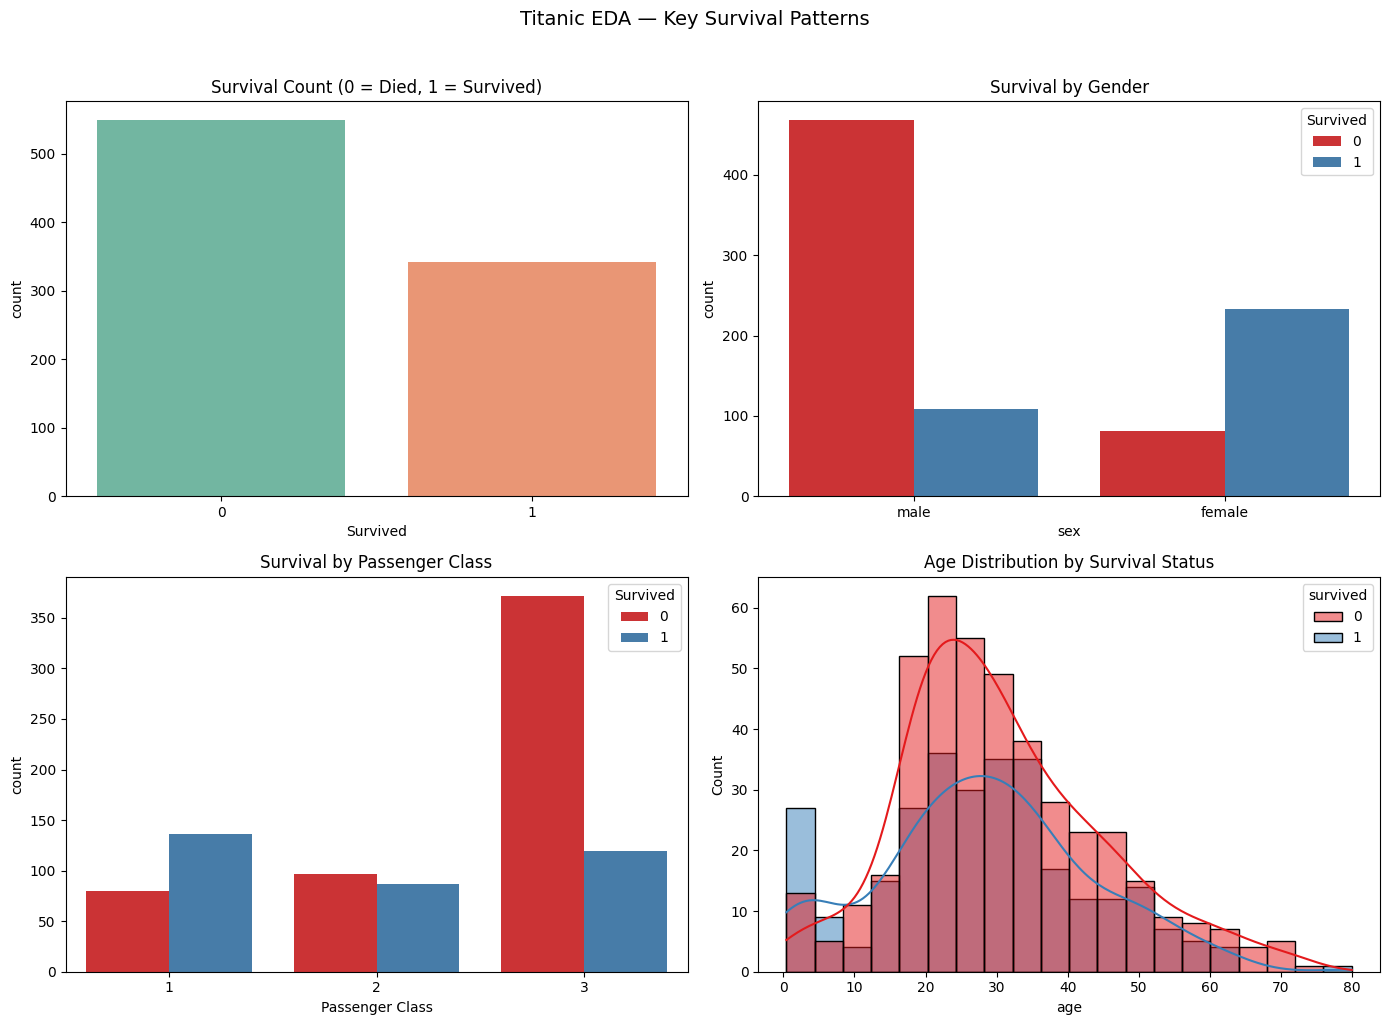

In [139]:
# — Chart 1: Overview panel (survival, gender, class, age) —
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=titanic_eda, x='survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Survival Count (0 = Died, 1 = Survived)')
axes[0, 0].set_xlabel('Survived')

sns.countplot(data=titanic_eda, x='sex', hue='survived', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Survival by Gender')
axes[0, 1].legend(title='Survived')

sns.countplot(data=titanic_eda, x='pclass', hue='survived', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Survival by Passenger Class')
axes[1, 0].set_xlabel('Passenger Class')
axes[1, 0].legend(title='Survived')

sns.histplot(data=titanic_eda, x='age', hue='survived', kde=True, ax=axes[1, 1], palette='Set1')
axes[1, 1].set_title('Age Distribution by Survival Status')

plt.suptitle('Titanic EDA — Key Survival Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\shash\AppData\Local\Temp\ipykernel_1852\1764015579.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic_eda, x='survived', y='fare', ax=axes[0], palette='Pastel1')


<Axes: xlabel='survived', ylabel='fare'>

Text(0.5, 1.0, 'Fare Distribution by Survival Status')

Text(0.5, 0, 'Survived (0 = Died, 1 = Survived)')

<Axes: >

Text(0.5, 1.0, 'Missing Values by Column')

Text(0, 0.5, 'Count')

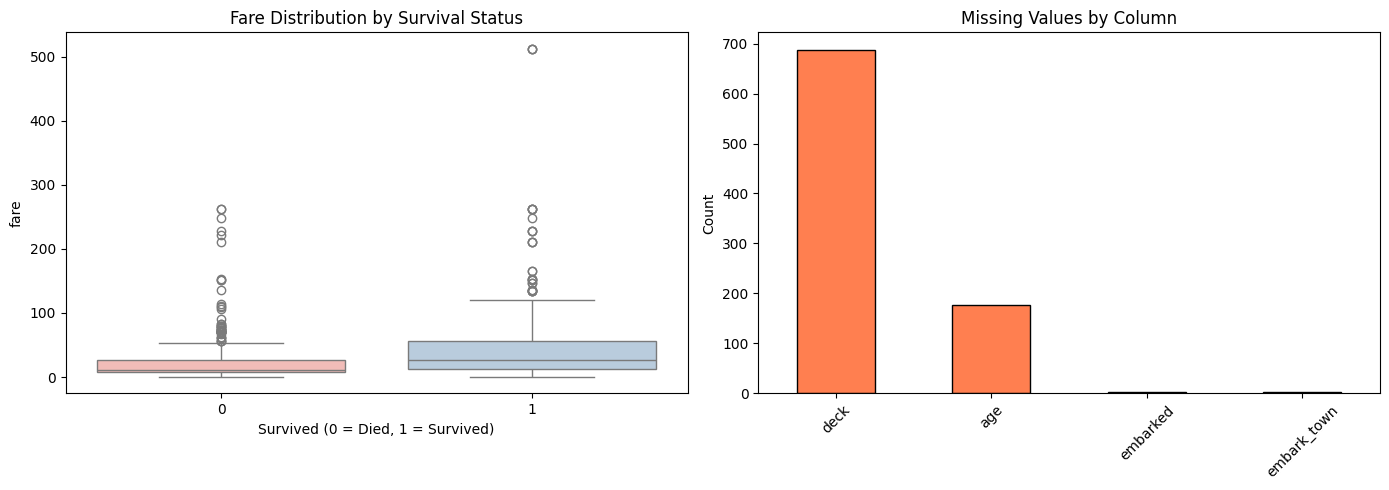

In [140]:
# — Chart 2: Fare distribution and missing values —
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=titanic_eda, x='survived', y='fare', ax=axes[0], palette='Pastel1')
axes[0].set_title('Fare Distribution by Survival Status')
axes[0].set_xlabel('Survived (0 = Died, 1 = Survived)')

missing = titanic_eda.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Missing Values by Column')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap — Numeric Features')

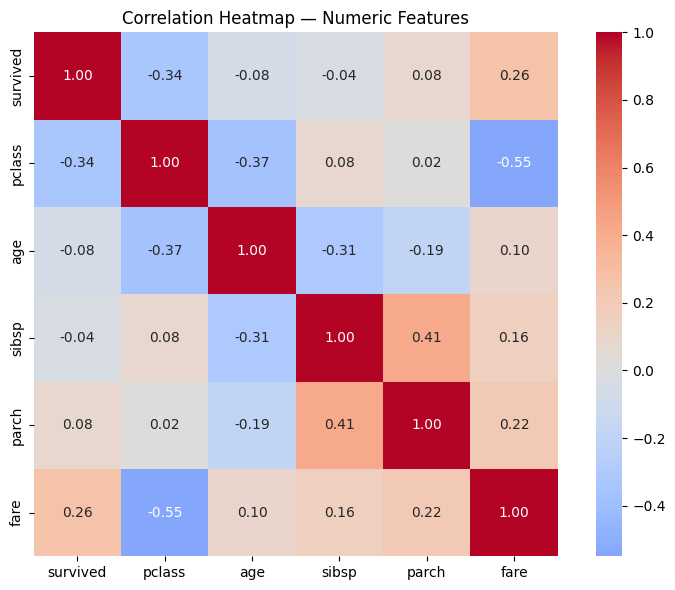

In [141]:
# — Chart 3: Correlation heatmap for numeric features —
numeric_cols = titanic_eda.select_dtypes(include='number').columns
corr = titanic_eda[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [142]:
# =============================================================================
# LOAD TITANIC DATA
# =============================================================================
# Load the built-in Titanic dataset from seaborn and preview first/last rows
titanic = sns.load_dataset('titanic')
titanic.head()
titanic.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [143]:
# =============================================================================
# PROGRESS BAR DEMO (tqdm)
# =============================================================================
# Demonstrate tqdm progress bar utility
from tqdm import tqdm
from time import sleep
with tqdm(total=100) as pbar:
    for i in range(10):
        sleep(0.1)
    pbar.update(10)

 10%|█         | 10/100 [00:01<00:09,  9.97it/s]

True

 10%|█         | 10/100 [00:01<00:09,  9.94it/s]


In [144]:
# =============================================================================
# DROP REDUNDANT / LEAKAGE COLUMNS
# =============================================================================
# Remove columns that duplicate information or would leak the target variable
# Note: 'deck' is kept here because it is imputed later in the missing-value section
titanic.drop(['alive', 'class','who', 'embark_town', 'alone', 'adult_male']
,axis=1,inplace=True)


# Preview cleaned dataframe
titanic.head()

# Check data types and non-null counts
titanic.info()

# Explore embarked port distribution before handling missing values
titanic['embarked'].value_counts()

# Find the most frequent embarkation port (used for imputation)
titanic['embarked'].mode()

# Inspect rows with missing embarked values
titanic.iloc[[61,684],:]

titanic.info()

# Fill missing embarked values with the mode (most common port: Southampton)
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

titanic.info()

# Summary of remaining missing values across all columns
titanic.isna().sum()

titanic.shape

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    object  
 8   deck      203 non-null    category
dtypes: category(1), float64(2), int64(4), object(2)
memory usage: 57.0+ KB


embarked
S    644
C    168
Q     77
Name: count, dtype: int64

0    S
Name: embarked, dtype: object

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
61,1,1,female,38.0,0,0,80.0,NaN,B
684,0,2,male,60.0,1,1,39.0,S,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    object  
 8   deck      203 non-null    category
dtypes: category(1), float64(2), int64(4), object(2)
memory usage: 57.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    object  
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      0
deck        688
dtype: int64

(891, 9)

In [145]:
# =============================================================================
# REMOVE DUPLICATE ROWS
# =============================================================================
# drop duplicates
titanic = titanic.drop_duplicates()
titanic.shape

(784, 9)

In [146]:
# =============================================================================
# EXPLORE MISSING AGE VALUES
# =============================================================================
# Isolate passengers with missing age for inspection
titanic_age_missing = titanic[titanic['age'].isna()]
titanic_age_missing.head()
titanic_age_missing.shape

# Inspect specific rows of interest
titanic.iloc[[19,26,28],:]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
5,0,3,male,NaN,0,0,8.4583,Q,NaN
17,1,2,male,NaN,0,0,13.0000,S,NaN
19,1,3,female,NaN,0,0,7.2250,C,NaN
26,0,3,male,NaN,0,0,7.2250,C,NaN
28,1,3,female,NaN,0,0,7.8792,Q,NaN


(106, 9)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
19,1,3,female,NaN,0,0,7.2250,C,NaN
26,0,3,male,NaN,0,0,7.2250,C,NaN
28,1,3,female,NaN,0,0,7.8792,Q,NaN


In [147]:
# =============================================================================
# RENAME COLUMNS FOR CLARITY
# =============================================================================
# Standardize column names to descriptive lowercase labels
titanic = titanic.rename(columns = {'sex':'gender', 'sibsp':'siblings_spouse',
'parch':'parents_child','Survived':'survived',
'Pclass':'plcass',
'Age':'age','Fare':'fare', 'Embarked':'embarked'})
titanic.head()

titanic.info()

titanic.columns

titanic['embarked'].value_counts()

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   survived         784 non-null    int64   
 1   pclass           784 non-null    int64   
 2   gender           784 non-null    object  
 3   age              678 non-null    float64 
 4   siblings_spouse  784 non-null    int64   
 5   parents_child    784 non-null    int64   
 6   fare             784 non-null    float64 
 7   embarked         784 non-null    object  
 8   deck             202 non-null    category
dtypes: category(1), float64(2), int64(4), object(2)
memory usage: 56.2+ KB


Index(['survived', 'pclass', 'gender', 'age', 'siblings_spouse',
       'parents_child', 'fare', 'embarked', 'deck'],
      dtype='object')

embarked
S    570
C    155
Q     59
Name: count, dtype: int64

In [148]:
# =============================================================================
# DECK COLUMN — MISSING VALUE TREATMENT
# =============================================================================
# Convert deck to object type and fill missing deck values with 'Not Assigned'
# (Must run before categorical encoding so deck is not dropped and median fill works)
titanic.deck = titanic.deck.astype('object')

titanic['deck'] = titanic['deck'].fillna('Not Assigned')

titanic.info()

titanic.deck.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    object 
 3   age              678 non-null    float64
 4   siblings_spouse  784 non-null    int64  
 5   parents_child    784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    object 
 8   deck             784 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 61.2+ KB


np.int64(0)

In [149]:
# =============================================================================
# ENCODE CATEGORICAL VARIABLES AS INTEGER CODES
# =============================================================================
# Convert object-type columns to numeric category codes for modeling
for x in titanic.columns:
    if titanic[x].dtype == 'object':
        titanic[x]=pd.Categorical(titanic[x]).codes

titanic.head()

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,0,3,1,22.0,1,0,7.2500,2,7
1,1,1,0,38.0,1,0,71.2833,0,2
2,1,3,0,26.0,0,0,7.9250,2,7
3,1,1,0,35.0,1,0,53.1000,2,2
4,0,3,1,35.0,0,0,8.0500,2,7


In [150]:
# =============================================================================
# IMPUTE MISSING AGE WITH MEDIAN
# =============================================================================
# Compute median age and fill missing age values
titanic['age'].median()

titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic.info()

# Fill any remaining numeric missing values with column medians
titanic= titanic.fillna(titanic.median())
titanic.info()

titanic.iloc[[19,26,28],:]

np.float64(28.25)

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    int8   
 3   age              784 non-null    float64
 4   siblings_spouse  784 non-null    int64  
 5   parents_child    784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    int8   
 8   deck             784 non-null    int8   
dtypes: float64(2), int64(4), int8(3)
memory usage: 45.2 KB
<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    int8   
 3   a

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
19,1,3,0,28.25,0,0,7.2250,0,7
26,0,3,1,28.25,0,0,7.2250,0,7
28,1,3,0,28.25,0,0,7.8792,1,7


In [151]:
# =============================================================================
# HANDLE REMAINING EMBARKED MISSING VALUES
# =============================================================================
titanic_embark_missing = titanic[titanic['embarked'].isna()]
titanic_embark_missing

titanic['embarked'].mode()

titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

titanic.iloc[[61,684],:]

# Sample and inspect the cleaned dataset
titanic.head(10)
titanic.sample(10)
titanic.tail(10)
titanic.info()

titanic.columns

titanic.info()

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck


0    2
Name: embarked, dtype: int8

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
62,0,1,1,45.0,1,0,83.475,2,2
775,0,3,1,18.0,0,0,7.750,2,7


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,0,3,1,22.00,1,0,7.2500,2,7
1,1,1,0,38.00,1,0,71.2833,0,2
2,1,3,0,26.00,0,0,7.9250,2,7
3,1,1,0,35.00,1,0,53.1000,2,2
4,0,3,1,35.00,0,0,8.0500,2,7
5,0,3,1,28.25,0,0,8.4583,1,7
6,0,1,1,54.00,0,0,51.8625,2,4
7,0,3,1,2.00,3,1,21.0750,2,7
8,1,3,0,27.00,0,2,11.1333,2,7
9,1,2,0,14.00,1,0,30.0708,0,7


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
486,1,1,0,35.00,1,0,90.0000,2,2
34,0,1,1,28.00,1,0,82.1708,0,7
286,1,3,1,30.00,0,0,9.5000,2,7
344,0,2,1,36.00,0,0,13.0000,2,7
457,1,1,0,28.25,1,0,51.8625,2,3
224,1,1,1,38.00,1,0,90.0000,2,2
508,0,3,1,28.00,0,0,22.5250,2,7
119,0,3,0,2.00,4,2,31.2750,2,7
277,0,2,1,28.25,0,0,0.0000,2,7
80,0,3,1,22.00,0,0,9.0000,2,7


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
879,1,1,0,56.00,0,1,83.1583,0,2
880,1,2,0,25.00,0,1,26.0000,2,7
881,0,3,1,33.00,0,0,7.8958,2,7
882,0,3,0,22.00,0,0,10.5167,2,7
883,0,2,1,28.00,0,0,10.5000,2,7
885,0,3,0,39.00,0,5,29.1250,1,7
887,1,1,0,19.00,0,0,30.0000,2,1
888,0,3,0,28.25,1,2,23.4500,2,7
889,1,1,1,26.00,0,0,30.0000,0,2
890,0,3,1,32.00,0,0,7.7500,1,7


<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    int8   
 3   age              784 non-null    float64
 4   siblings_spouse  784 non-null    int64  
 5   parents_child    784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    int8   
 8   deck             784 non-null    int8   
dtypes: float64(2), int64(4), int8(3)
memory usage: 45.2 KB


Index(['survived', 'pclass', 'gender', 'age', 'siblings_spouse',
       'parents_child', 'fare', 'embarked', 'deck'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    int8   
 3   age              784 non-null    float64
 4   siblings_spouse  784 non-null    int64  
 5   parents_child    784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    int8   
 8   deck             784 non-null    int8   
dtypes: float64(2), int64(4), int8(3)
memory usage: 45.2 KB


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,0.626276,29.650408,0.522959,0.415816,34.711740,1.529337,5.808673
std,0.492507,0.855056,0.484101,13.734925,0.986231,0.836922,52.160151,0.803350,2.151747
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,5.000000
50%,0.000000,3.000000,1.000000,28.250000,0.000000,0.000000,15.900000,2.000000,7.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.109350,2.000000,7.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,7.000000


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0.00,0.0,1.0,0.0,0.420,0.0,0.0,0.0000,0.0,0.0
0.01,0.0,1.0,0.0,1.000,0.0,0.0,0.0000,0.0,0.0
0.05,0.0,1.0,0.0,5.000,0.0,0.0,7.2250,0.0,1.0
0.50,0.0,3.0,1.0,28.250,0.0,0.0,15.9000,2.0,7.0
0.95,1.0,3.0,1.0,55.425,2.0,2.0,120.0000,2.0,7.0
0.99,1.0,3.0,1.0,65.170,4.0,4.0,262.3750,2.0,7.0
1.00,1.0,3.0,1.0,80.000,8.0,6.0,512.3292,2.0,7.0


<Axes: >

count    784.000000
mean      33.598625
std       44.436915
min        0.000000
25%        8.050000
50%       15.900000
75%       34.109350
max      249.006220
Name: fare, dtype: float64

<Axes: >

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   gender           784 non-null    int8   
 3   age              784 non-null    float64
 4   siblings_spouse  784 non-null    int64  
 5   parents_child    784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         784 non-null    int8   
 8   deck             784 non-null    int8   
dtypes: float64(2), int64(4), int8(3)
memory usage: 45.2 KB


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,0.626276,29.650408,0.522959,0.415816,33.598625,1.529337,5.808673
std,0.492507,0.855056,0.484101,13.734925,0.986231,0.836922,44.436915,0.803350,2.151747
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,5.000000
50%,0.000000,3.000000,1.000000,28.250000,0.000000,0.000000,15.900000,2.000000,7.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.109350,2.000000,7.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,249.006220,2.000000,7.000000


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,0.626276,29.587194,0.506378,0.406888,33.598625,1.529337,5.808673
std,0.492507,0.855056,0.484101,13.539720,0.899814,0.790430,44.436915,0.803350,2.151747
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,5.000000
50%,0.000000,3.000000,1.000000,28.250000,0.000000,0.000000,15.900000,2.000000,7.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.109350,2.000000,7.000000
max,1.000000,3.000000,1.000000,65.170000,4.000000,4.000000,249.006220,2.000000,7.000000


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,0.626276,29.587194,0.506378,0.406888,33.598625,1.529337,5.808673
std,0.492507,0.855056,0.484101,13.539720,0.899814,0.790430,44.436915,0.803350,2.151747
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,5.000000
50%,0.000000,3.000000,1.000000,28.250000,0.000000,0.000000,15.900000,2.000000,7.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.109350,2.000000,7.000000
max,1.000000,3.000000,1.000000,65.170000,4.000000,4.000000,249.006220,2.000000,7.000000


,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,0,3,1,22.0,1,0,7.2500,2,7
1,1,1,0,38.0,1,0,71.2833,0,2
2,1,3,0,26.0,0,0,7.9250,2,7
3,1,1,0,35.0,1,0,53.1000,2,2
4,0,3,1,35.0,0,0,8.0500,2,7


survived
0    461
1    323
dtype: int64

(784, 9)

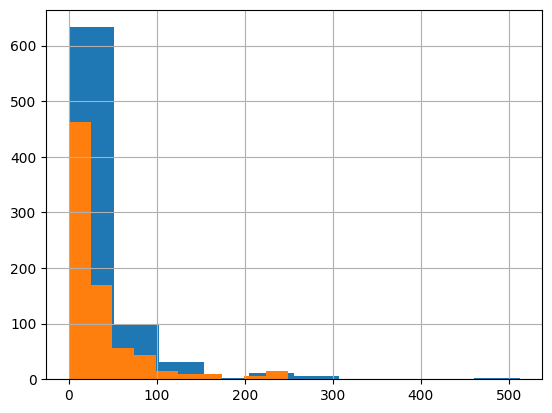

In [152]:
# =============================================================================
# DESCRIPTIVE STATISTICS AND OUTLIER ANALYSIS
# =============================================================================
# Summary statistics for all numeric columns
titanic.describe()

# Percentile distribution to identify potential outliers
titanic.quantile((0, 0.01,0.05, 0.5, 0.95,0.99, 1.0))

# Visualize fare distribution before clipping outliers
titanic.fare.hist()


# Clip fare outliers at the 99th percentile upper bound
titanic.fare = np.clip(titanic.fare,0,249.00622 )

titanic.fare.describe()

titanic.fare.hist()

titanic.info()

titanic.describe()

# Clip all numeric columns to their 1st and 99th percentile bounds
for x in titanic.columns:
    outlier = titanic[x].quantile([0.01,0.99]).values
    titanic[x] = np.clip(titanic[x], outlier[0], outlier[1])


titanic.describe()

# prompt: read a csv file

#df = pd.read_csv('filename.csv')


titanic.describe()
titanic.head()

# Check class balance of the target variable (survived)
titanic.groupby('survived').size()

titanic.shape

In [153]:
# =============================================================================
# PREPARE FEATURES (X) AND TARGET (y)
# =============================================================================
# Import scikit-learn modules for splitting, metrics, and logistic regression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression


# Separate features from target variable
x = titanic.drop(['survived'], axis = 1, inplace=False)
y = titanic['survived']
x.shape
print('\n')
y.shape

titanic.describe()

(784, 8)

(784,)

,survived,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.411990,2.243622,0.626276,29.587194,0.506378,0.406888,33.598625,1.529337,5.808673
std,0.492507,0.855056,0.484101,13.539720,0.899814,0.790430,44.436915,0.803350,2.151747
min,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,22.000000,0.000000,0.000000,8.050000,1.000000,5.000000
50%,0.000000,3.000000,1.000000,28.250000,0.000000,0.000000,15.900000,2.000000,7.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.109350,2.000000,7.000000
max,1.000000,3.000000,1.000000,65.170000,4.000000,4.000000,249.006220,2.000000,7.000000


In [154]:
# =============================================================================
# FEATURE SCALING — MinMaxScaler (demonstration)
# =============================================================================
from sklearn.preprocessing import MinMaxScaler
scld_titanic = MinMaxScaler(feature_range= (0,1))
titanic_transformed = scld_titanic.fit_transform(x)
scld_titanic_df = pd.DataFrame(titanic_transformed, columns = x.columns)
scld_titanic_df.head()
scld_titanic_df.describe()

,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,1.0,1.0,0.327256,0.25,0.0,0.029116,1.0,1.000000
1,0.0,0.0,0.576593,0.25,0.0,0.286271,0.0,0.285714
2,1.0,0.0,0.389590,0.00,0.0,0.031827,1.0,1.000000
3,0.0,0.0,0.529843,0.25,0.0,0.213248,1.0,0.285714
4,1.0,1.0,0.529843,0.00,0.0,0.032329,1.0,1.000000


,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000
mean,0.621811,0.626276,0.445492,0.126594,0.101722,0.134931,0.764668,0.829810
std,0.427528,0.484101,0.210998,0.224954,0.197608,0.178457,0.401675,0.307392
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.327256,0.000000,0.000000,0.032329,0.500000,0.714286
50%,1.000000,1.000000,0.424653,0.000000,0.000000,0.063854,1.000000,1.000000
75%,1.000000,1.000000,0.545426,0.250000,0.250000,0.136982,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [155]:
# =============================================================================
# FEATURE SCALING — StandardScaler (used for modeling)
# =============================================================================
from sklearn.preprocessing import StandardScaler
scld_titanic = StandardScaler()
titanic_transformed = scld_titanic.fit_transform(x)
scld_titanic_df = pd.DataFrame(titanic_transformed, columns = x.columns)
scld_titanic_df.head()
np.round(scld_titanic_df.describe(),2)

,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
0,0.885158,0.772490,-0.560723,0.548933,-0.515096,-0.593323,0.586250,0.554009
1,-1.455362,-1.294515,0.621739,0.548933,-0.515096,0.848590,-1.904915,-1.771168
2,0.885158,-1.294515,-0.265108,-0.563117,-0.515096,-0.578123,0.586250,0.554009
3,-1.455362,-1.294515,0.400028,0.548933,-0.515096,0.439135,0.586250,-1.771168
4,0.885158,0.772490,0.400028,-0.563117,-0.515096,-0.575308,0.586250,0.554009


,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
count,784.00,784.00,784.00,784.00,784.00,784.00,784.00,784.00
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.46,-1.29,-2.11,-0.56,-0.52,-0.76,-1.90,-2.70
25%,-1.46,-1.29,-0.56,-0.56,-0.52,-0.58,-0.66,-0.38
50%,0.89,0.77,-0.10,-0.56,-0.52,-0.40,0.59,0.55
75%,0.89,0.77,0.47,0.55,0.75,0.01,0.59,0.55
max,0.89,0.77,2.63,3.89,4.55,4.85,0.59,0.55


In [160]:
# =============================================================================
# TRAIN / TEST SPLIT
# =============================================================================
# Split in Train and Test data
x_train, x_test, y_train, y_test = train_test_split(scld_titanic_df, y, test_size=0.2, random_state=999)
x_train.shape
y_train.shape
x_test.shape
y_test.shape

x_train
y_train
x_test

# Check survival rate (% positive class) in train and test sets
np.round(y_train.sum()/y_train.count()*100,2)
print('\n')
np.round(y_test.sum()/y_test.count()*100,2)

(627, 8)

(627,)

(157, 8)

(157,)

,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
375,-0.285102,0.77249,-1.964898,0.548933,0.750845,-0.334364,0.58625,0.554009
711,0.885158,0.77249,0.104412,-0.563117,-0.515096,-0.581501,0.58625,0.554009
473,-0.285102,0.77249,-0.486819,1.660983,0.750845,-0.497621,0.58625,0.554009
566,-0.285102,0.77249,0.104412,0.548933,0.750845,-0.165478,0.58625,0.554009
409,-1.455362,0.77249,1.656394,-0.563117,-0.515096,-0.069775,0.58625,-1.771168
...,...,...,...,...,...,...,...,...
225,-0.285102,0.77249,0.252220,-0.563117,-0.515096,-0.480169,0.58625,0.554009
712,-1.455362,0.77249,0.695643,-0.563117,-0.515096,-0.756580,0.58625,-2.701239
481,0.885158,0.77249,-0.098824,-0.563117,-0.515096,-0.430066,0.58625,0.554009
348,0.885158,0.77249,-0.782435,-0.563117,-0.515096,-0.581501,0.58625,0.554009


407    1
805    0
529    0
637    0
449    1
      ..
239    0
806    0
538    0
379    0
499    0
Name: survived, Length: 627, dtype: int64

,pclass,gender,age,siblings_spouse,parents_child,fare,embarked,deck
459,-1.455362,0.772490,0.473932,-0.563117,-0.515096,-0.164633,0.586250,-0.841097
203,0.885158,-1.294515,-0.191204,-0.563117,-0.515096,-0.578123,0.586250,0.554009
624,-0.285102,0.772490,0.695643,-0.563117,-0.515096,-0.171107,0.586250,0.554009
320,-0.285102,-1.294515,-0.412916,-0.563117,-0.515096,-0.463844,0.586250,-0.376062
376,0.885158,0.772490,-0.634627,-0.563117,-0.515096,-0.581501,0.586250,0.554009
...,...,...,...,...,...,...,...,...
293,-0.285102,0.772490,0.991259,0.548933,0.750845,-0.165478,0.586250,0.554009
110,0.885158,0.772490,2.629709,-0.563117,-0.515096,-0.582064,-0.659333,0.554009
692,0.885158,0.772490,-0.098824,0.548933,2.016787,-0.228529,0.586250,0.554009
428,-0.285102,-1.294515,-0.486819,-0.563117,-0.515096,-0.446016,-1.904915,-1.306133


np.float64(40.83)

np.float64(42.68)

In [163]:
# =============================================================================
# LOGISTIC REGRESSION MODEL
# =============================================================================
# Initialize logistic regression classifier
log = LogisticRegression()

log

# Fit the model on training data
log.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1])

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        90
           1       0.76      0.70      0.73        67

    accuracy                           0.78       157
   macro avg       0.77      0.77      0.77       157
weighted avg       0.78      0.78      0.78       157



array([[75, 15],
       [20, 47]])

<Axes: >

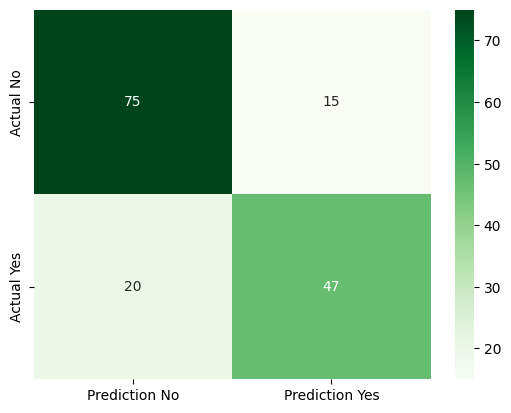

0.7770700636942676

In [164]:
# =============================================================================
# PREDICTIONS AND EVALUATION
# =============================================================================
# Generate class predictions on the test set
predicted = log.predict(x_test)
predicted

from sklearn import metrics
print((metrics.classification_report(y_test, predicted)))

# Build confusion matrix comparing actual vs predicted labels
df_confusion = metrics.confusion_matrix(y_test,predicted)
df_confusion


import seaborn as sns
import matplotlib.pyplot as plt
# Visualize confusion matrix as a heatmap
sns.heatmap(df_confusion, cmap = 'Greens',xticklabels=['Prediction No','Prediction Yes'],
yticklabels=['Actual No','Actual Yes'], annot=True, fmt='d')
plt.show();

# Overall accuracy score
metrics.accuracy_score(y_test, predicted)


In [165]:
# =============================================================================
# MODEL INTERPRETATION — COEFFICIENTS
# =============================================================================
# Raw model coefficients (log-odds impact of each feature)
log.coef_

x.columns

# Combine feature names with their coefficients for readability
coeff = pd.concat([pd.DataFrame(x.columns), pd.DataFrame(np.transpose(log.coef_))],axis =1 )
coeff.columns = ('Variable', 'Coeff')

coeff

# =============================================================================
# PROBABILITY PREDICTIONS AND THRESHOLD ANALYSIS
# =============================================================================
# Find out probability of the classes and predicted classes
predicted_prob = log.predict_proba(x_test)
predicted_prob_df = pd.DataFrame(predicted_prob)
predicted_classes_df = pd.DataFrame(predicted)
y_actual_df = pd.DataFrame(y_test.values)
predicted_df = pd.concat([predicted_prob_df, predicted_classes_df, y_actual_df], axis=1)
predicted_df.columns = ['Prob_0','Prob_1','Predicted_Class', 'Actual_Class']
predicted_df.sample(20)


predicted_prob

array([[-0.7810787 , -1.20232634, -0.57710644, -0.30202042, -0.16693514,
         0.02030072, -0.14805882, -0.19244068]])

Index(['pclass', 'gender', 'age', 'siblings_spouse', 'parents_child', 'fare',
       'embarked', 'deck'],
      dtype='object')

,Variable,Coeff
0,pclass,-0.781079
1,gender,-1.202326
2,age,-0.577106
3,siblings_spouse,-0.302020
4,parents_child,-0.166935
5,fare,0.020301
6,embarked,-0.148059
7,deck,-0.192441


,Prob_0,Prob_1,Predicted_Class,Actual_Class
36,0.885475,0.114525,0,0
43,0.518393,0.481607,0,1
26,0.925215,0.074785,0,1
133,0.468508,0.531492,1,1
144,0.843171,0.156829,0,0
130,0.056063,0.943937,1,1
75,0.340025,0.659975,1,1
151,0.563999,0.436001,0,0
139,0.415071,0.584929,1,1
51,0.899625,0.100375,0,0


array([[0.55397344, 0.44602656],
       [0.36648402, 0.63351598],
       [0.82161992, 0.17838008],
       [0.14546149, 0.85453851],
       [0.84317581, 0.15682419],
       [0.85898305, 0.14101695],
       [0.1203916 , 0.8796084 ],
       [0.53805585, 0.46194415],
       [0.35717302, 0.64282698],
       [0.32849211, 0.67150789],
       [0.8049969 , 0.1950031 ],
       [0.91066252, 0.08933748],
       [0.14053402, 0.85946598],
       [0.80303192, 0.19696808],
       [0.20489829, 0.79510171],
       [0.53863242, 0.46136758],
       [0.83888713, 0.16111287],
       [0.74881101, 0.25118899],
       [0.87802515, 0.12197485],
       [0.06159685, 0.93840315],
       [0.27139185, 0.72860815],
       [0.86190473, 0.13809527],
       [0.75697559, 0.24302441],
       [0.54108302, 0.45891698],
       [0.44893086, 0.55106914],
       [0.24285506, 0.75714494],
       [0.92521486, 0.07478514],
       [0.44515852, 0.55484148],
       [0.91673444, 0.08326556],
       [0.88859559, 0.11140441],
       [0.